In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split

from scipy.stats import skew, kurtosis
from scipy.signal import welch

In [39]:
# ============================================================
# Data Split
# ============================================================

def split_train_validation_array(X, val_ratio=0.2, random_state=42):
    return train_test_split(
        X,
        test_size=val_ratio,
        shuffle=True,
        random_state=random_state
    )


# ============================================================
# Feature Extraction
# ============================================================

def extract_raw_features(X):
    return X


def extract_statistical_features(X, use_spectral=False):

    mean = np.mean(X, axis=1)
    std = np.std(X, axis=1)
    skewness = skew(X, axis=1)
    kurt = kurtosis(X, axis=1)
    max_val = np.max(X, axis=1)
    min_val = np.min(X, axis=1)
    rms = np.sqrt(np.mean(X**2, axis=1))
    ptp = max_val - min_val

    features = np.vstack([
        mean,
        std,
        skewness,
        kurt,
        max_val,
        min_val,
        rms,
        ptp
    ]).T

    if use_spectral:
        spectral_energy = []
        for signal in X:
            f, Pxx = welch(signal, nperseg=256)
            spectral_energy.append(np.sum(Pxx))
        spectral_energy = np.array(spectral_energy).reshape(-1, 1)
        features = np.hstack([features, spectral_energy])

    return features.astype(np.float32)


# ============================================================
# Scaling
# ============================================================

def global_scaling(train_X, val_X, test_X):
    scaler = StandardScaler()
    scaler.fit(train_X)

    return (
        scaler.transform(train_X),
        scaler.transform(val_X),
        scaler.transform(test_X),
        scaler
    )


# ============================================================
# Hyperparameter Tuning
# ============================================================

def tune_isolation_forest(X_train, X_val, random_state=42):

    param_grid = {
        "n_estimators": [100, 200],
        "max_samples": ["auto", 256],
        "contamination": [0.01, 0.05]
    }

    best_model = None
    best_score = np.inf

    for n in param_grid["n_estimators"]:
        for ms in param_grid["max_samples"]:
            for c in param_grid["contamination"]:

                model = IsolationForest(
                    n_estimators=n,
                    max_samples=ms,
                    contamination=c,
                    random_state=random_state,
                    n_jobs=-1
                )

                model.fit(X_train)

                scores = -model.decision_function(X_val)
                metric = np.mean(scores)

                if metric < best_score:
                    best_score = metric
                    best_model = model

    return best_model


# ============================================================
# Evaluation
# ============================================================

def evaluate_model(model, X, y_true):

    scores = -model.decision_function(X)

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    idx = np.argmax(j_scores)
    optimal_threshold = thresholds[idx]

    y_pred = (scores >= optimal_threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    return {
        "scores": scores,
        "roc_auc": roc_auc,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": optimal_threshold,
        "confusion_matrix": cm,
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred)
    }


# ============================================================
# Visualization
# ============================================================

def plot_roc(fpr, tpr, roc_auc):
    plt.figure(figsize=(6, 6))
    
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random Classifier")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC)")
    
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm):
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"]
    )
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


def plot_score_histogram(scores, y_true):
    plt.figure(figsize=(7, 4))
    
    sns.histplot(scores[y_true == 0], bins=40, kde=True, stat="density", label="Normal", alpha=0.6)
    sns.histplot(scores[y_true == 1], bins=40, kde=True, stat="density", label="Anomaly", alpha=0.6)
    
    plt.xlabel("Anomaly Score")
    plt.ylabel("Density")
    plt.title("Anomaly Score Distribution")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_extreme_signals(X_raw, scores, y_true):

    normal_idx = np.where(y_true == 0)[0]
    anomaly_idx = np.where(y_true == 1)[0]

    best_normal = normal_idx[np.argmin(scores[normal_idx])]
    worst_normal = normal_idx[np.argmax(scores[normal_idx])]
    best_anomaly = anomaly_idx[np.argmax(scores[anomaly_idx])]
    worst_anomaly = anomaly_idx[np.argmin(scores[anomaly_idx])]

    indices = [best_normal, worst_normal, best_anomaly, worst_anomaly]
    titles = ["Best Normal", "Worst Normal", "Best Anomaly", "Worst Anomaly"]

    for idx, title in zip(indices, titles):
        plt.figure(figsize=(10, 3))
        plt.plot(X_raw[idx], linewidth=1)
        plt.title(title)
        plt.xlabel("Time Index")
        plt.ylabel("Amplitude")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

def plot_misclassified_signals(X_raw, scores, y_true, threshold, n_samples=2):

    # Predictions using threshold
    y_pred = (scores >= threshold).astype(int)

    # False Positives: predicted anomaly but actually normal
    fp_idx = np.where((y_pred == 1) & (y_true == 0))[0]

    # False Negatives: predicted normal but actually anomaly
    fn_idx = np.where((y_pred == 0) & (y_true == 1))[0]

    # Select up to n_samples from each
    fp_idx = fp_idx[:n_samples]
    fn_idx = fn_idx[:n_samples]

    # --------------------------------------------------------
    # Plot False Positives
    # --------------------------------------------------------
    for i, idx in enumerate(fp_idx):
        plt.figure(figsize=(10, 3))
        plt.plot(X_raw[idx], linewidth=1)
        plt.title(f"False Positive {i+1} | Score: {scores[idx]:.4f}")
        plt.xlabel("Time Index")
        plt.ylabel("Amplitude")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # Plot False Negatives
    # --------------------------------------------------------
    for i, idx in enumerate(fn_idx):
        plt.figure(figsize=(10, 3))
        plt.plot(X_raw[idx], linewidth=1)
        plt.title(f"False Negative {i+1} | Score: {scores[idx]:.4f}")
        plt.xlabel("Time Index")
        plt.ylabel("Amplitude")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

def debug_false_negative(X_raw, scores, y_true, threshold):

    y_pred = (scores >= threshold).astype(int)

    fn_idx = np.where((y_pred == 0) & (y_true == 1))[0]

    if len(fn_idx) == 0:
        print("No False Negatives.")
        return

    idx = fn_idx[0]

    print("Index:", idx)
    print("Ground Truth Label:", y_true[idx])
    print("Predicted Label:", y_pred[idx])
    print("Score:", scores[idx])
    print("Threshold:", threshold)

    plt.figure(figsize=(10, 3))
    plt.plot(X_raw[idx])
    plt.title("False Negative Debug")
    plt.show()

In [34]:
BASE_PATH = "/kaggle/input/datasets/nagasai524/anomaly-detection-in-helicopter/"

train_df = pd.read_csv(
    BASE_PATH + "train_df.csv",
    header=None,
    skiprows=1,
    index_col=0
)

validation_df = pd.read_csv(
    BASE_PATH + "validation_df.csv",
    header=None,
    skiprows=1,
    index_col=0
)

groundtruth_df = pd.read_csv(BASE_PATH + "dfvalid_groundtruth.csv")

X_train_raw = train_df.values.astype(np.float32)
X_test_raw = validation_df.values.astype(np.float32)
y_test = groundtruth_df["anomaly"].values.astype(int)

In [35]:
FEATURE_MODE = "stat"  # "raw" or "stat"

# Split
X_train, X_val = split_train_validation_array(X_train_raw)

# Feature extraction
if FEATURE_MODE == "raw":
    X_train_f = extract_raw_features(X_train)
    X_val_f = extract_raw_features(X_val)
    X_test_f = extract_raw_features(X_test_raw)
else:
    X_train_f = extract_statistical_features(X_train)
    X_val_f = extract_statistical_features(X_val)
    X_test_f = extract_statistical_features(X_test_raw)

# Scaling
X_train_s, X_val_s, X_test_s, scaler = global_scaling(
    X_train_f, X_val_f, X_test_f
)

# Train
best_model = tune_isolation_forest(X_train_s, X_val_s)

# Evaluate
results = evaluate_model(best_model, X_test_s, y_test)

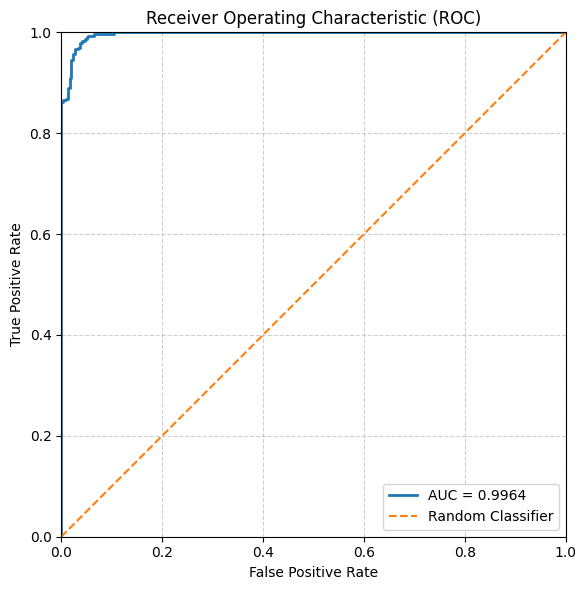

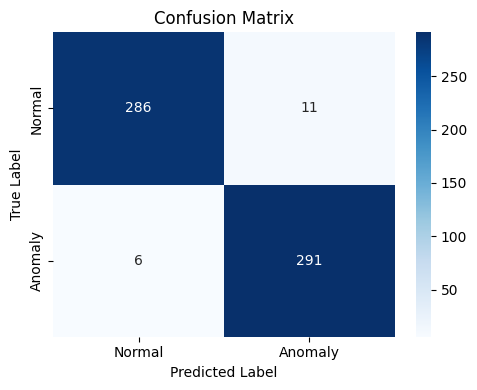

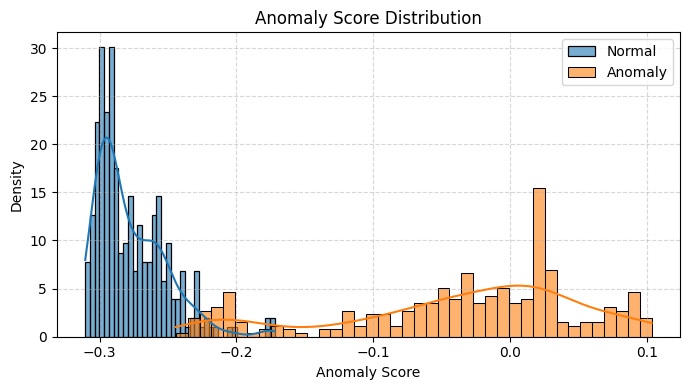

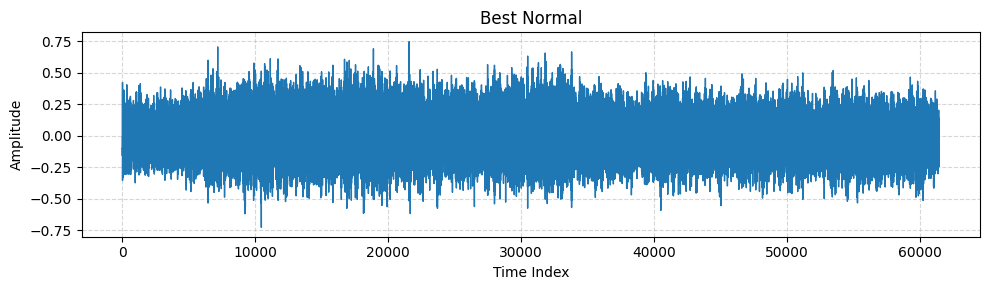

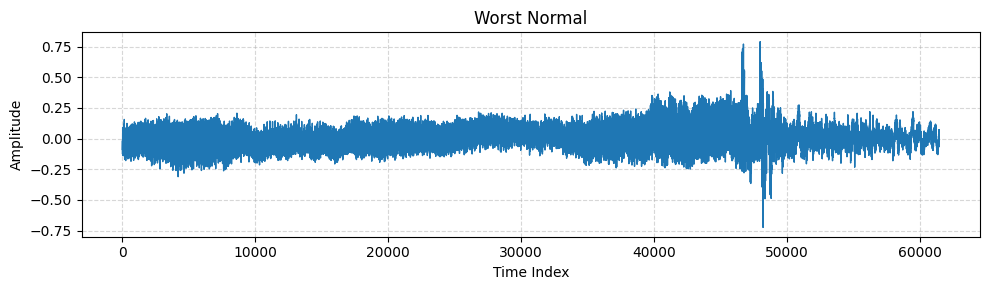

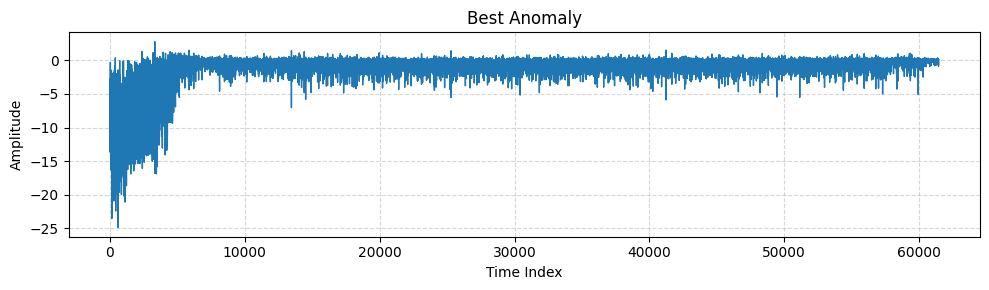

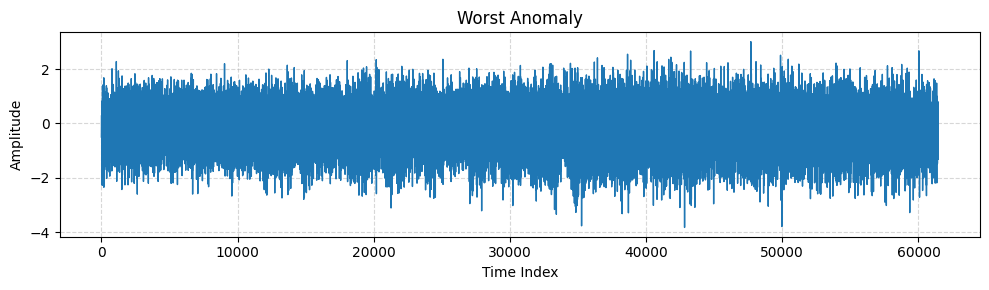

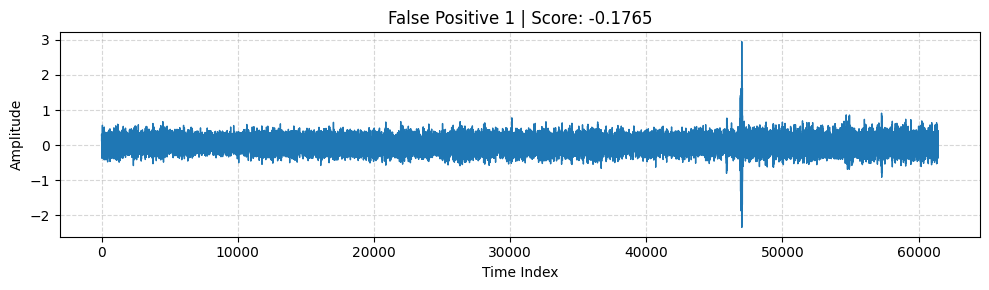

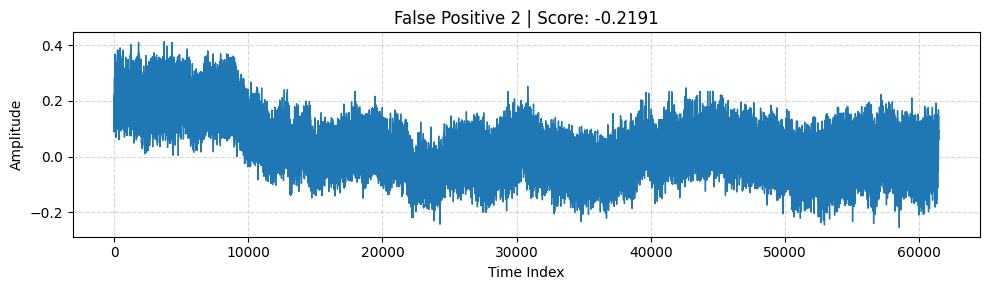

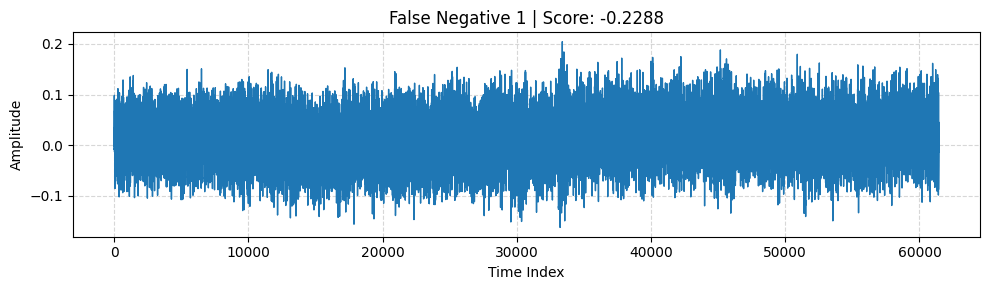

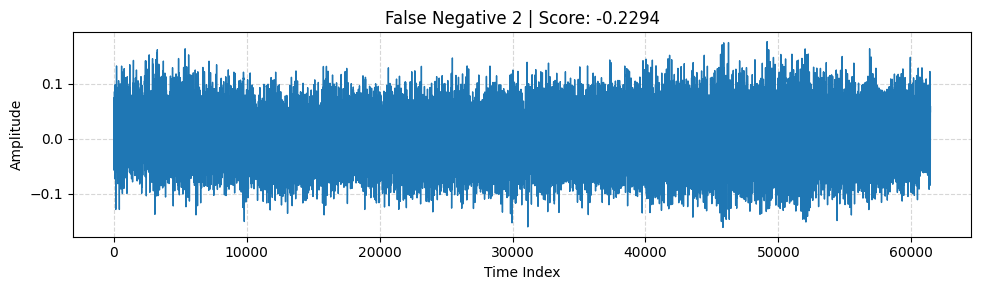

Index: 13
Ground Truth Label: 1
Predicted Label: 0
Score: -0.22880857434017404
Threshold: -0.22681465299573866


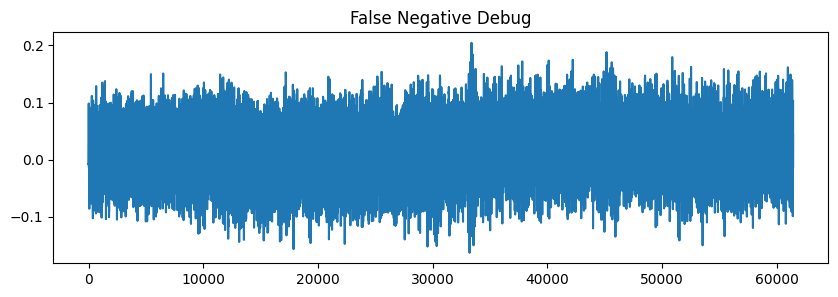

AUC: 0.9963835889761816
F1: 0.9716193656093489
Precision: 0.9635761589403974
Recall: 0.9797979797979798


In [40]:
# Visualize
plot_roc(results["fpr"], results["tpr"], results["roc_auc"])
plot_confusion_matrix(results["confusion_matrix"])
plot_score_histogram(results["scores"], y_test)
plot_extreme_signals(X_test_raw, results["scores"], y_test)
plot_misclassified_signals(
    X_test_raw,
    results["scores"],
    y_test,
    threshold=results["threshold"],
    n_samples=2
)
debug_false_negative(
    X_test_raw,
    results["scores"],
    y_test,
    results["threshold"]
)

print("AUC:", results["roc_auc"])
print("F1:", results["f1"])
print("Precision:", results["precision"])
print("Recall:", results["recall"])